# Tutorial: GABLS1 LES Intercomparison Study for Stable Boundary Layers

In [1]:
from IPython.display import display, Markdown
from datetime import datetime, timezone
display(Markdown(f"*Last run: {datetime.now(timezone.utc).strftime('%B %d, %Y at %H:%M UTC')}*"))

*Last run: June 24, 2026 at 09:27 UTC*

This tutorial walks through a complete JAX-ALFA simulation from scratch using the GABLS1 LES intercomparison study as the working example.
By the end you will have:

1. Created a run directory with a `Config.py`, initial-condition files, and a surface
   boundary-condition file.
2. Launched the solver and understood the log output.
3. Loaded the statistics output and produced the standard mean-profile plots.

**References:**

Beare, R. J., and Coauthors. (2006). An intercomparison of large-eddy simulations of the stable boundary layer. Boundary-Layer Meteorology, 118, 247–272.

Basu, S. and Porté-Agel, F. (2006). Large-eddy simulation of stably stratified atmospheric boundary layer turbulence: A scale-dependent dynamic modeling approach. Journal of the  Atmospheric Sciences, 63, 2074–2091.

Dai, Y., Basu, S., Maronga, B., and de Roode, S. R. (2020). Addressing the grid-size sensitivity issue in large-eddy simulations of stable boundary layers. Boundary-Layer Meteorology, 178, 63–89.

**SGS model used here:** Locally Averaged Scale-Dependent Dynamic (LASDD) – Smagorinsky (`optSgs = 1`).

---
## 1. Case Overview

The GABLS1 case simulates a stable nocturnal boundary layer driven by a prescribed
surface cooling rate. It is widely used as a reference benchmark because the forcing
is simple, the quasi-steady state is reached within 9 h, and a large ensemble of
LES results is available in the literature.

| Parameter | Value |
|---|---|
| Domain | 400 m × 400 m × 400 m |
| Grid | 128 × 128 × 128 |
| Grid spacing | ≈ 3.15 m (isotropic) |
| Geostrophic wind | $U_g = 8$ m s$^{-1}$, $V_g = 0$ |
| Coriolis parameter | $f = 1.39 \times 10^{-4}$ s$^{-1}$ (73° N) |
| Roughness lengths | $z_{0m} = z_{0T} = 0.1$ m |
| Initial surface temperature | 265 K |
| Surface cooling rate | 0.25 K hr$^{-1}$ |
| Simulation duration | 9 h |
| Time step | 0.1 s |
| SGS model | LASDD-SM (`optSgs = 1`) |
| Precision | double (`use_double_precision = True`) |
| Averaging window | hours 8–9 (quasi-steady state) |

---
## 2. Prerequisites

Before running this tutorial, ensure JAX-ALFA and its dependencies are
installed. See the [Installation](../modules/Installation) page for
step-by-step instructions.

---
## 3. Directory Layout

A JAX-ALFA run lives in its own directory. The packaged GABLS1 reference run
used in this tutorial has the structure below:

```
examples/SBL_GABLS1/runs/128x128x128_LASDD_SM_DP/
├── Config.py
├── CreateInputs_SBL_GABLS1.py
├── CreateSurfaceBC_GABLS1.py
├── input/
│   ├── vel.ini
│   ├── TH.ini
│   └── SurfaceBC.npz
└── output/
    ├── ALFA_Statistics_Iteration_*.npz
    └── ALFA_3DFields_Iteration_*.npz
```

The notebook reads this packaged run for post-processing. When setting up your
own case, copy the same directory pattern, edit `Config.py`, regenerate the
`input/` files, and point `JAXALFA_RUNDIR` to your new run directory.

In [37]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def find_repo_root(start=None):
    """Locate the JAXALFA0.1 repository root from common notebook launch paths."""
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError(
        'Could not locate the JAXALFA0.1 root. Launch the notebook from the '
        'repository, or set RunDir manually in the next cell.'
    )


BaseDir = find_repo_root()
RunDir = BaseDir / 'examples' / 'SBL_GABLS1' / 'runs' / '128x128x128_LASDD_SM_DP'

print('Repository root:', BaseDir)
print('Run directory  :', RunDir)
print('Run exists     :', RunDir.exists())

Repository root: /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/JAXALFA0.1
Run directory  : /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/JAXALFA0.1/examples/SBL_GABLS1/runs/128x128x128_LASDD_SM_DP
Run exists     : True


---
## 4. Step 1 - Inspect `Config.py`

`Config.py` is the main file to edit when changing the simulation setup. It
contains the domain sizes, time step, SGS options, surface boundary condition,
and output intervals. The cell below prints the packaged GABLS1 namelist so the
settings used for the reference output are visible in the tutorial.

In [38]:
config_path = RunDir / 'Config.py'

if not config_path.exists():
    raise FileNotFoundError(
        f'Missing {config_path}. Check RunDir or copy the packaged GABLS1 run directory.'
    )

config_text = config_path.read_text()
print(config_text)

# Copyright (C) 2025 Sukanta Basu
#
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.
#
# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU General Public License for more details.
#
# You should have received a copy of the GNU General Public License
# along with this program.  If not, see <https://www.gnu.org/licenses/>.

"""
File: Config.py

:Author: Sukanta Basu
:AI Assistance: Claude.AI (Anthropic) is used for documentation,
                code restructuring, and performance optimization
:Date: 2026-05-20
:Description: Stable BL benchmark after Beare et al. (2006), GABLS1.
              Domain 400x400x400 m; surface cooling 0.25 K/hr.
     

In [39]:
# Extract grid and timing parameters from Config.py
_cfg = {}
exec(config_text, _cfg)
nz                 = int(_cfg['nz'])
l_z                = float(_cfg['l_z'])
dt_cfg             = float(_cfg['dt'])
SimTime_cfg        = float(_cfg['SimTime'])
OutputInterval_sec = float(_cfg['OutputInterval_sec'])
dz = l_z / (nz - 1)

print(f'nz={nz}, l_z={l_z} m, dz={dz:.4f} m')
print(f'dt={dt_cfg} s, SimTime={SimTime_cfg} s ({SimTime_cfg/3600:.1f} h)')
print(f'OutputInterval_sec={OutputInterval_sec} s')

nz=128, l_z=400.0 m, dz=3.1496 m
dt=0.1 s, SimTime=32400.0 s (9.0 h)
OutputInterval_sec=60.0 s


**Key parameters to understand:**

| Parameter | Meaning |
|---|---|
| `use_double_precision` | `True` → float64; `False` → float32 |
| `optGPU` | `1` → NVIDIA GPU via JAX/CUDA; `0` → CPU |
| `optSurfBC = 2` | Surface temperature prescribed from `SurfaceBC.npz` |
| `optSgs = 1` | LASDD-SM: tuning-free, scale-dependent dynamic closure |
| `FGR = 2` | Test filter is twice the grid filter (dealiasing inactive) |
| `z_damping = 300` | Rayleigh sponge activates above 300 m to suppress reflections |

---
## 5. Step 2 — Create Initial Conditions

Initial conditions follow the GABLS1 protocol (Beare et al. 2006):

- $u = U_g = 8$ m s$^{-1}$, $v = w = 0$ everywhere.
- $\theta = 265$ K for $z \le 100$ m; $\theta = 265 + 0.01(z-100)$ K above.
- Small random perturbations below 50 m to trigger the turbulent cascade.

The run directory ships with a ready-to-use script **`CreateInputs_SBL_GABLS1.py`**
that writes `input/vel.ini` (three-column ASCII: $u$, $v$, $w$) and
`input/TH.ini` (one-column ASCII: potential temperature), both stored in
Fortran column-major order.

Run it once before the first simulation:

```bash
cd /path/to/runs/128x128x128_LASDD_SM_DP
python CreateInputs_SBL_GABLS1.py
```

Expected output:
```
GABLS1 initial conditions written to .../input
  Grid: nx=128, ny=128, nz=128, dz=3.1496 m
  vel.ini shape: (2097152, 3)
  TH.ini  shape: (2097152,)
  TH range: 264.990 - 265.010 K
```

The initial temperature profile is plotted below for reference.

The temperature profile can be visualised to confirm the initial stratification:

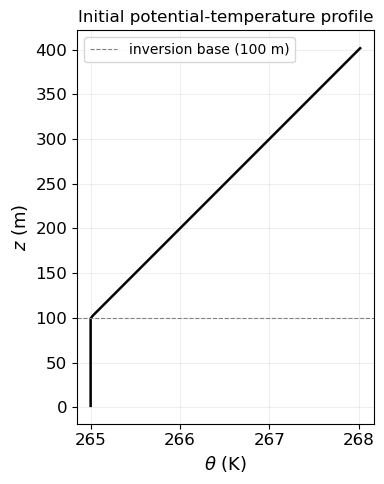

In [40]:
# Reconstruct the deterministic part of the initial temperature profile
# (nz, l_z, dz loaded from Config.py in the cell above)
z_plot = np.array([(k + 0.5) * dz for k in range(nz)])

TH_profile = np.where(z_plot <= 100.0, 265.0, 265.0 + 0.01 * (z_plot - 100.0))

fig, ax = plt.subplots(figsize=(4, 5))
ax.plot(TH_profile, z_plot, 'k-', linewidth=1.8)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, label='inversion base (100 m)')
ax.set_xlabel(r'$\theta$ (K)', fontsize=13)
ax.set_ylabel(r'$z$ (m)',      fontsize=13)
ax.set_title('Initial potential-temperature profile', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Step 3 — Create the Surface Boundary-Condition File

Because `optSurfBC = 2`, the solver reads the surface temperature at each time
step from `input/SurfaceBC.npz`.  The GABLS1 protocol prescribes a linear
cooling rate of 0.25 K hr$^{-1}$:

$$T_s(t) = 265 - 0.25 \cdot \frac{t}{3600}$$

Over 9 h the surface cools from 265 K to 262.75 K.

The run directory ships with **`CreateSurfaceBC_GABLS1.py`**, which reads
`dt` and `SimTime` directly from `Config.py` and writes the full time series
to `input/SurfaceBC.npz`.

Run it once before the first simulation:

```bash
cd /path/to/runs/128x128x128_LASDD_SM_DP
python CreateSurfaceBC_GABLS1.py
```

Expected output:
```
Surface BC file written to .../input/SurfaceBC.npz
  Mode: linear cooling
  nsteps + 1    = 324001  (dt = 0.1 s, SimTime = 32400.0 s)
  T_s(t=0)      = 265.0000 K
  T_s(t=SimTime)= 262.7500 K
  T_s range     : [262.7500, 265.0000] K
```

The prescribed cooling curve is shown below.

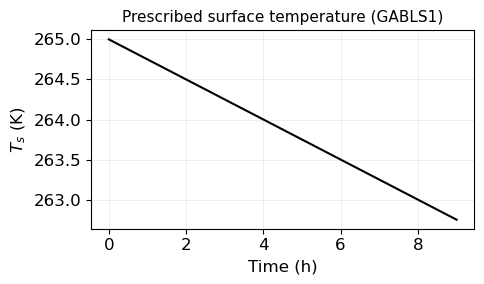

In [41]:
# Prescribed surface temperature — GABLS1 linear cooling
# (dt_cfg, SimTime_cfg loaded from Config.py in the cell above)
nsteps   = int(np.ceil(SimTime_cfg / dt_cfg))
t_series = np.arange(0, nsteps + 1) * dt_cfg
T_sfc    = 265.0 - 0.25 * (t_series / 3600.0)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(t_series / 3600, T_sfc, 'k-', linewidth=1.5)
ax.set_xlabel('Time (h)',   fontsize=12)
ax.set_ylabel(r'$T_s$ (K)', fontsize=12)
ax.set_title('Prescribed surface temperature (GABLS1)', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Step 4 — Launch the Solver

With `Config.py`, `vel.ini`, `TH.ini`, and `SurfaceBC.npz` in place, launch
JAX-ALFA from the terminal:

```bash
export JAXALFA_RUNDIR=/path/to/128x128x128_LASDD_SM_DP
python /path/to/JAXALFA0.1/src/Main.py
```

The solver writes statistics to `output/ALFA_Statistics_Iteration_*.npz`
every `OutputInterval_sec` seconds (60 s → one file per minute → 540 files
for a 9-hour run).

**Progress monitoring:** the log file `run.log` (or stdout) prints a one-line
summary every `OutputInterval_sec` seconds showing the current simulation
time, wall-clock time per step, and the instantaneous friction velocity $u_*$.

---
## 8. Step 5 - Load and Inspect the Output

Each statistics file contains horizontally averaged profiles sampled every
`SampleInterval_sec` seconds (10 s) and time-averaged over `OutputInterval_sec`
(60 s). The arrays stored in each `.npz` file are:

| Array | Description | Grid |
|---|---|---|
| `U`, `V`, `TH` | Mean velocity components and potential temperature | half levels |
| `u2`, `v2`, `w2` | Resolved velocity variances | half / full levels |
| `TH2` | Resolved temperature variance | half levels |
| `uv`, `uw`, `vw` | Resolved momentum fluxes | half / full levels |
| `txy`, `txz`, `tyz` | SGS stress components | half / full levels |
| `wTH` | Resolved heat flux | full levels |
| `qz` | SGS heat flux | full levels |

In [42]:
OutputDir = RunDir / 'output'


def get_stat_files(output_dir):
    """Return statistics files sorted by iteration number."""
    pattern = str(output_dir / 'ALFA_Statistics_Iteration_*.npz')
    files = sorted(
        glob.glob(pattern),
        key=lambda x: int(re.search(r'Iteration_(\d+)', x).group(1))
    )
    return files


stat_files = get_stat_files(OutputDir)
print(f'{len(stat_files)} statistics files found in {OutputDir}')

if not stat_files:
    raise FileNotFoundError(
        'No ALFA_Statistics_Iteration_*.npz files were found. Run the solver first, '
        'or point RunDir to a completed GABLS1 run.'
    )

with np.load(stat_files[0]) as d:
    print('Arrays in each file:', sorted(d.keys()))
    print('Profile length (nz):', d['U'].shape)

540 statistics files found in /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/JAXALFA0.1/examples/SBL_GABLS1/runs/128x128x128_LASDD_SM_DP/output
Arrays in each file: ['Beta1', 'Beta2', 'Cs2PrRatio', 'Cs2_1', 'Cs2_2', 'M_sfc', 'Q', 'Q2', 'TH', 'TH2', 'U', 'Ugal', 'V', 'W', 'ZeRo1D', 'dQdz', 'dTHdz', 'dUdz', 'dVdz', 'qHz', 'qm_sfc', 'qz', 'qz_sfc', 'txy', 'txz', 'tyz', 'u2', 'uTH', 'ustar', 'uv', 'uw', 'v2', 'vTH', 'vw', 'w2', 'wQ', 'wTH']
Profile length (nz): (128,)


### 8.1 Quasi-steady state averaging window

The GABLS1 benchmark defines the quasi-steady state as hours 8–9.  We average
over all statistics files in that window.

In [43]:
# (nz, l_z, OutputInterval_sec loaded from Config.py in the cell above)
T_start, T_end = 8 * 3600, 9 * 3600
i_start = int(T_start / OutputInterval_sec) - 1
i_end   = int(T_end   / OutputInterval_sec) - 1

# Vertical grids
z   = np.array([(k + 0.5) * l_z / (nz - 1) for k in range(nz)])   # half levels
z_w = np.array([k          * l_z / (nz - 1) for k in range(nz)])   # full levels

print(f'Averaging window: file indices {i_start}–{i_end} '
      f'({i_end - i_start + 1} files)')
print(f'Half-level range: {z[0]:.2f}–{z[-1]:.2f} m')

Averaging window: file indices 479–539 (61 files)
Half-level range: 1.57–401.57 m


In [44]:
def load_time_average(stat_files, i_start, i_end):
    """Load and time-average statistics over [i_start, i_end] inclusive."""
    if len(stat_files) <= i_end:
        raise ValueError(
            f'Need at least {i_end + 1} statistics files for the 8-9 h average; '
            f'found {len(stat_files)}.'
        )

    keys = ['U', 'V', 'TH', 'u2', 'v2', 'w2', 'TH2',
            'uv', 'uw', 'vw', 'txy', 'txz', 'tyz', 'wTH', 'qz']
    stacks = {k: [] for k in keys}

    for f in stat_files:
        with np.load(f) as d:
            missing = [k for k in keys if k not in d]
            if missing:
                raise KeyError(f'{f} is missing arrays: {missing}')
            for k in keys:
                stacks[k].append(d[k])

    sl = slice(i_start, i_end + 1)
    return {k: np.mean(np.array(stacks[k])[sl], axis=0) for k in keys}


avg = load_time_average(stat_files, i_start, i_end)

# Convenience: total (resolved + SGS) fluxes
uw_tot  = avg['uw']  + avg['txz']
vw_tot  = avg['vw']  + avg['tyz']
wTH_tot = avg['wTH'] + avg['qz']
S_mag   = np.sqrt(avg['U']**2 + avg['V']**2)

print('Time-averaged profiles loaded.')
print(f"  U range  : {avg['U'].min():.2f} - {avg['U'].max():.2f} m/s")
print(f"  TH range : {avg['TH'].min():.2f} - {avg['TH'].max():.2f} K")

Time-averaged profiles loaded.
  U range  : 1.62 - 9.46 m/s
  TH range : 263.19 - 268.02 K


---
## 9. Mean Wind and Temperature Profiles

The panels below show the streamwise velocity $U$, cross-stream velocity $V$,
wind-speed magnitude $S$, and mean potential temperature $\theta$ averaged
over hours 8–9.

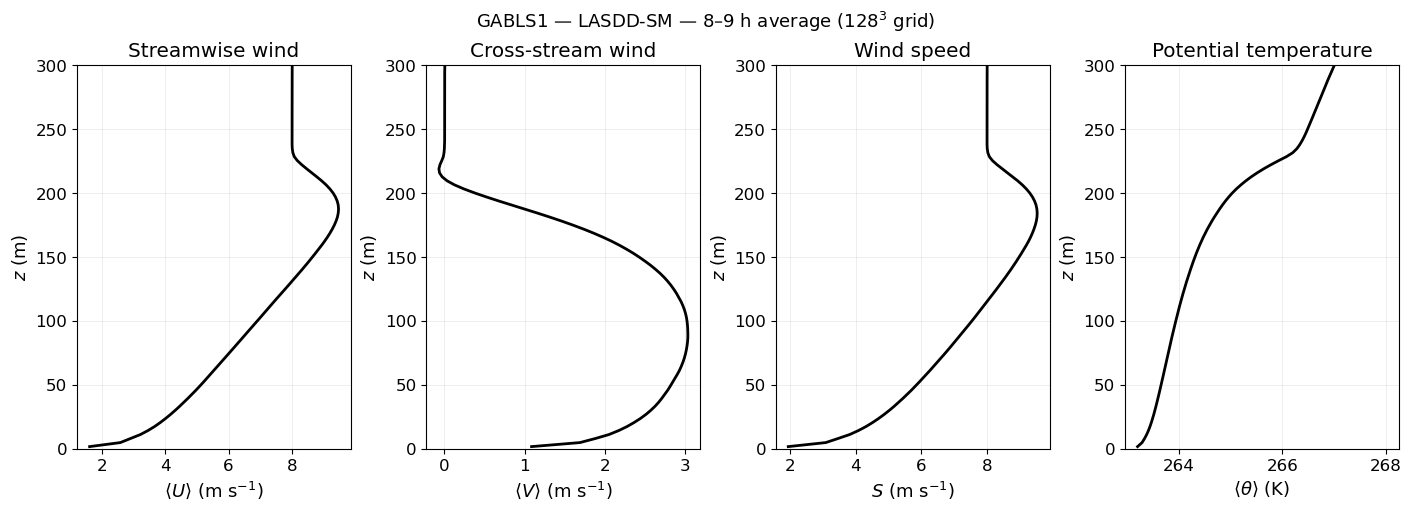

In [45]:
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13})

fig, axs = plt.subplots(1, 4, figsize=(14, 5), constrained_layout=True)

axs[0].plot(avg['U'], z, 'k-', linewidth=2)
axs[0].set_xlabel(r'$\langle U \rangle$ (m s$^{-1}$)')
axs[0].set_ylabel(r'$z$ (m)')
axs[0].set_title('Streamwise wind')

axs[1].plot(avg['V'], z, 'k-', linewidth=2)
axs[1].set_xlabel(r'$\langle V \rangle$ (m s$^{-1}$)')
axs[1].set_title('Cross-stream wind')

axs[2].plot(S_mag, z, 'k-', linewidth=2)
axs[2].set_xlabel(r'$S$ (m s$^{-1}$)')
axs[2].set_title('Wind speed')

axs[3].plot(avg['TH'], z, 'k-', linewidth=2)
axs[3].set_xlabel(r'$\langle \theta \rangle$ (K)')
axs[3].set_title('Potential temperature')

for ax in axs:
    ax.set_ylim(0, 300)
    ax.grid(alpha=0.3)
    ax.set_ylabel(r'$z$ (m)')

fig.suptitle('GABLS1 — LASDD-SM — 8–9 h average ($128^3$ grid)', fontsize=13)
plt.show()

---
## 10. Momentum and Heat Fluxes

The total vertical flux is the sum of the resolved turbulent flux and the SGS
contribution.  In a well-resolved LES the SGS fraction should be small in the
bulk and larger only near the surface.

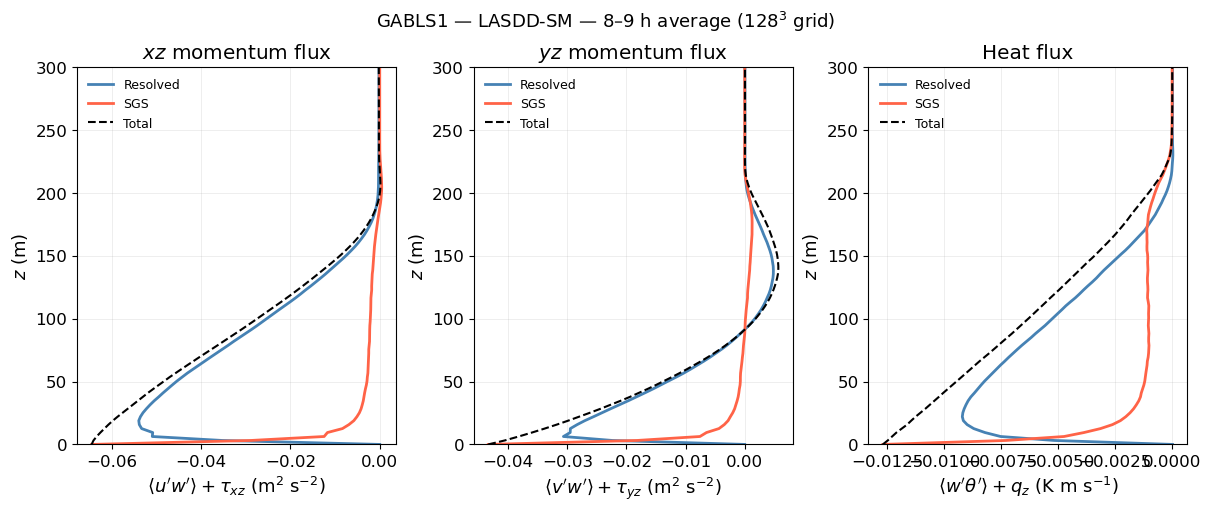

In [46]:
fig, axs = plt.subplots(1, 3, figsize=(12, 5), constrained_layout=True)

# Total uw stress
axs[0].plot(avg['uw'],  z_w, color='steelblue', linewidth=2, label='Resolved')
axs[0].plot(avg['txz'], z_w, color='tomato',    linewidth=2, label='SGS')
axs[0].plot(uw_tot,     z_w, 'k--',             linewidth=1.5, label='Total')
axs[0].set_xlabel(r"$\langle u'w' \rangle + \tau_{xz}$ (m$^2$ s$^{-2}$)")
axs[0].set_title(r'$xz$ momentum flux')

# Total vw stress
axs[1].plot(avg['vw'],  z_w, color='steelblue', linewidth=2, label='Resolved')
axs[1].plot(avg['tyz'], z_w, color='tomato',    linewidth=2, label='SGS')
axs[1].plot(vw_tot,     z_w, 'k--',             linewidth=1.5, label='Total')
axs[1].set_xlabel(r"$\langle v'w' \rangle + \tau_{yz}$ (m$^2$ s$^{-2}$)")
axs[1].set_title(r'$yz$ momentum flux')

# Total heat flux
axs[2].plot(avg['wTH'], z_w, color='steelblue', linewidth=2, label='Resolved')
axs[2].plot(avg['qz'],  z_w, color='tomato',    linewidth=2, label='SGS')
axs[2].plot(wTH_tot,    z_w, 'k--',             linewidth=1.5, label='Total')
axs[2].set_xlabel(r"$\langle w'\theta' \rangle + q_z$ (K m s$^{-1}$)")
axs[2].set_title('Heat flux')

for ax in axs:
    ax.set_ylim(0, 300)
    ax.set_ylabel(r'$z$ (m)')
    ax.legend(fontsize=9, frameon=False)
    ax.grid(alpha=0.3)

fig.suptitle('GABLS1 — LASDD-SM — 8–9 h average ($128^3$ grid)', fontsize=13)
plt.show()

---
## 11. Temporal Evolution of the Friction Velocity

The friction velocity $u_* = \bigl(-\langle u'w' \rangle_s\bigr)^{1/2}$ at
the surface provides a compact diagnostic of the boundary-layer spin-up and
quasi-steady approach.  We compute it from the total surface stress
(`uw_tot[0]`, `vw_tot[0]`) as a function of time.

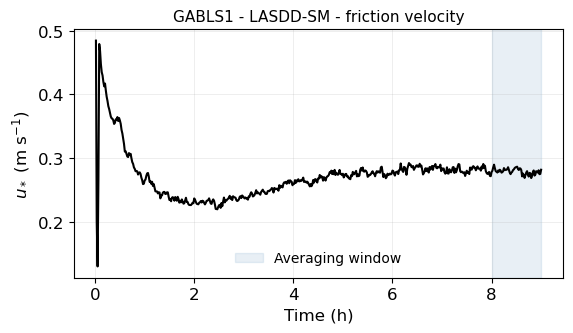

u* averaged over 8-9 h: 0.2788 m/s


In [47]:
ustar_series = []
time_series  = []

for idx, f in enumerate(stat_files):
    with np.load(f) as d:
        uw_surf  = d['uw'][0]  + d['txz'][0]
        vw_surf  = d['vw'][0]  + d['tyz'][0]
        tau_surf = np.sqrt(uw_surf**2 + vw_surf**2)
        ustar_series.append(np.sqrt(tau_surf))
    time_series.append((idx + 1) * OutputInterval_sec / 3600.0)  # hours

ustar_series = np.array(ustar_series)
time_series  = np.array(time_series)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(time_series, ustar_series, 'k-', linewidth=1.5)
ax.axvspan(8, 9, alpha=0.12, color='steelblue', label='Averaging window')
ax.set_xlabel('Time (h)', fontsize=12)
ax.set_ylabel(r'$u_*$ (m s$^{-1}$)', fontsize=12)
ax.set_title('GABLS1 - LASDD-SM - friction velocity', fontsize=11)
ax.legend(fontsize=10, frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

window = (time_series >= 8) & (time_series <= 9)
ustar_avg = np.mean(ustar_series[window])
print(f'u* averaged over 8-9 h: {ustar_avg:.4f} m/s')

---
## 12. Velocity Variances

Resolved velocity variances characterise the turbulent intensity in each
direction.  Under stable stratification the vertical component $\sigma_w^2$
is strongly suppressed compared to the horizontal components.

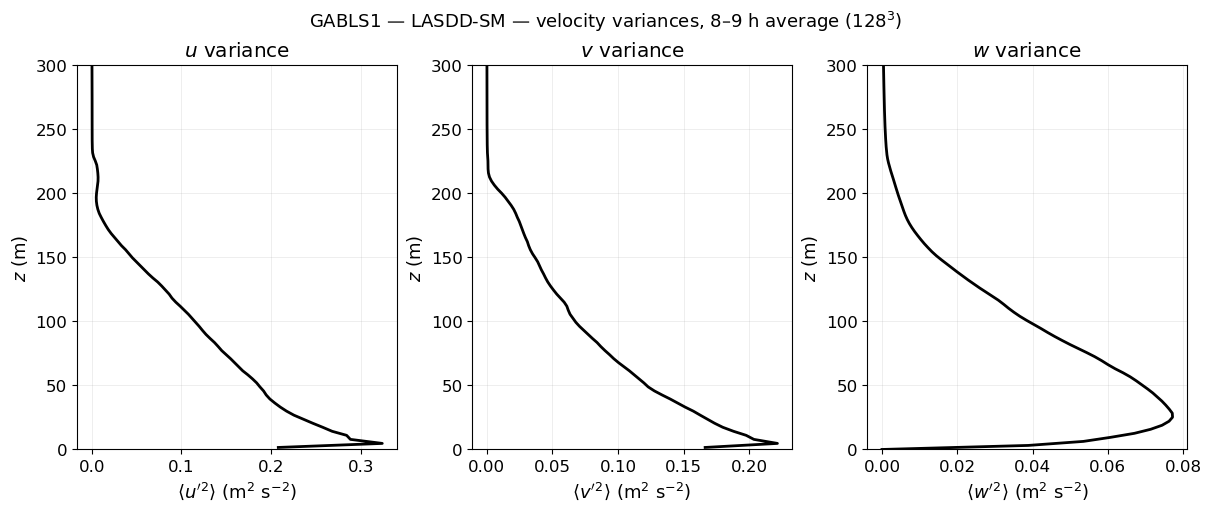

In [48]:
fig, axs = plt.subplots(1, 3, figsize=(12, 5), constrained_layout=True)

axs[0].plot(avg['u2'], z,   'k-', linewidth=2)
axs[0].set_xlabel(r"$\langle u'^2 \rangle$ (m$^2$ s$^{-2}$)")
axs[0].set_title(r'$u$ variance')

axs[1].plot(avg['v2'], z,   'k-', linewidth=2)
axs[1].set_xlabel(r"$\langle v'^2 \rangle$ (m$^2$ s$^{-2}$)")
axs[1].set_title(r'$v$ variance')

axs[2].plot(avg['w2'], z_w, 'k-', linewidth=2)
axs[2].set_xlabel(r"$\langle w'^2 \rangle$ (m$^2$ s$^{-2}$)")
axs[2].set_title(r'$w$ variance')

for ax in axs:
    ax.set_ylim(0, 300)
    ax.set_ylabel(r'$z$ (m)')
    ax.grid(alpha=0.3)

fig.suptitle('GABLS1 — LASDD-SM — velocity variances, 8–9 h average ($128^3$)', fontsize=13)
plt.show()

---
## 13. Next Steps

Now that you have a working GABLS1 run you can:

- **Change the SGS model** — edit `optSgs` in `Config.py` (1 = LASDD-SM, 2 = LASDD-WL, 3 = LAD-SM, 4 = LAD-WL) and re-run.
- **Change precision** — set `use_double_precision = False` for float32 and
  compare with the double-precision reference.
- **Change resolution** — adjust `nx, ny, nz` (and `dt` if needed for
  stability) to explore resolution sensitivity.
- **Explore the Case Studies** section for more complex examples (CBL, NBL,
  GABLS3, Wangara diurnal cycle).

See the **API Reference** section for a complete description of every
module and configuration parameter.